In [15]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [16]:
data = fetch_california_housing()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedianHouseValue")

print("Shape:", x.shape)
print("Features:", x.columns.tolist())

Shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [17]:
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [18]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedianHouseValue, dtype: float64

In [19]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## DECISION TREE REGRESSOR

In [21]:
dt_reg = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=8,
    min_samples_split=3,
    min_samples_leaf=2,
    splitter='best',
    random_state=2
)

In [22]:
dt_reg.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",2
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_

In [23]:
y_pred = dt_reg.predict(X_test)

In [24]:
print("Decision Tree Regressor Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

Decision Tree Regressor Performance:
MAE: 0.44196377960560507
MSE: 0.4176395231473704
RMSE: 0.6462503564001884
R²: 0.6899540008471217


In [25]:
for name, score in zip(data.feature_names, dt_reg.feature_importances_):
    print(f"{name}: {score:.4f}")

MedInc: 0.6534
HouseAge: 0.0418
AveRooms: 0.0280
AveBedrms: 0.0050
Population: 0.0096
AveOccup: 0.1329
Latitude: 0.0708
Longitude: 0.0585


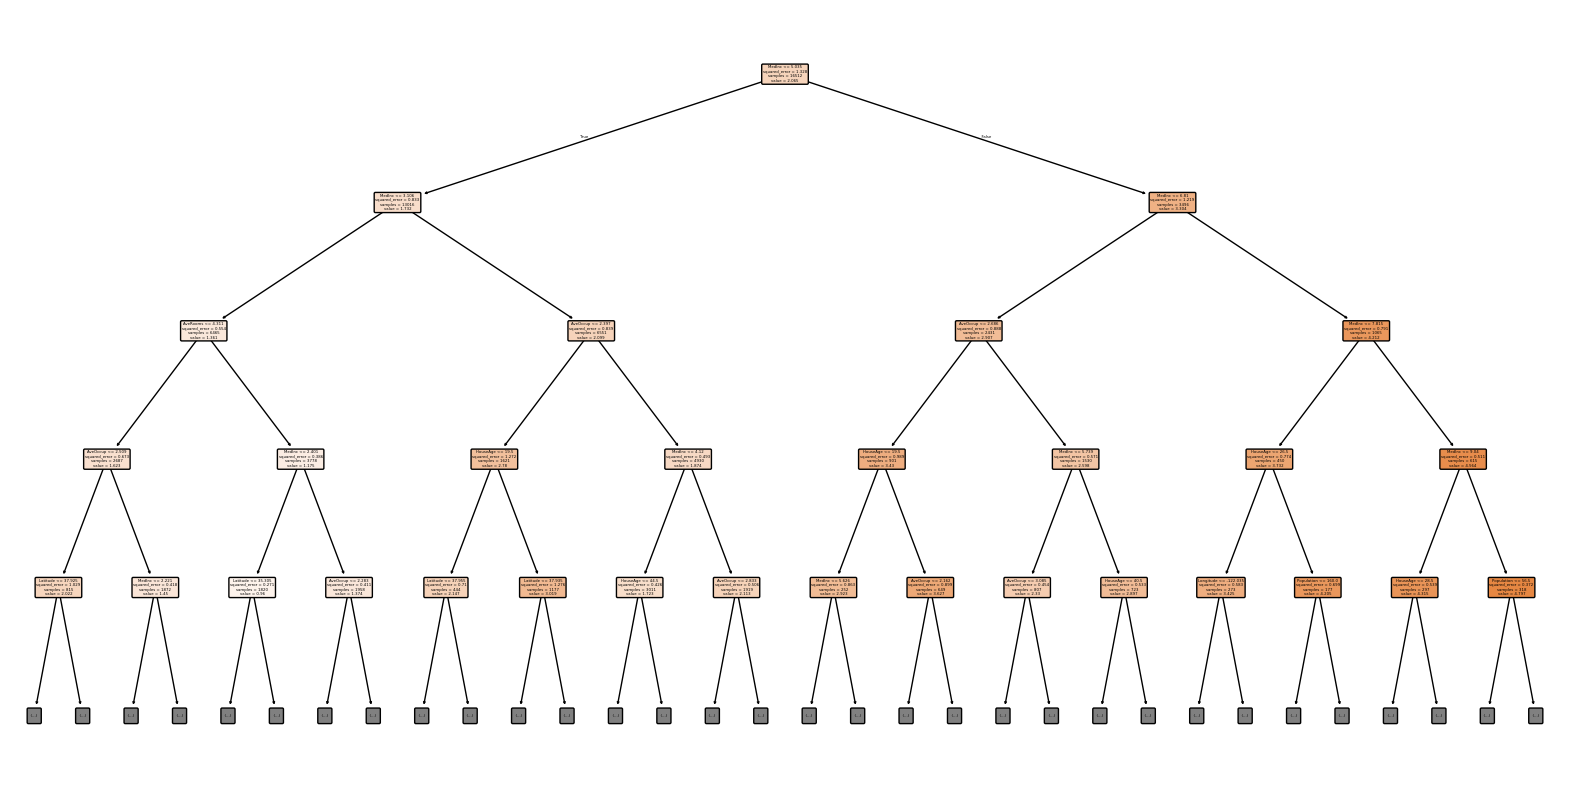

In [26]:
plt.figure(figsize=(20, 10))
plot_tree(dt_reg, feature_names=data.feature_names, filled=True, rounded=True, max_depth=4)
plt.show()

In [27]:
joblib.dump(dt_reg, 'decision_tree_regressor.pkl')
print("Model saved as 'decision_tree_regressor.pkl'")

Model saved as 'decision_tree_regressor.pkl'


In [33]:
loaded_dt_reg = joblib.load('decision_tree_regressor.pkl')

In [34]:
def predict_house_value_dt(features_list):
    #scaled = scaler.transform([features_list])
    pred = loaded_dt_reg.predict(features_list)[0]
    return float(pred)

In [35]:
test = pd.DataFrame([[8.3, 29, 6.5, 1.0, 400, 3.5, 34.2, -118.4]], columns=data.feature_names)

In [36]:
test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3,29,6.5,1.0,400,3.5,34.2,-118.4


In [37]:
print(predict_house_value_dt(test))

4.8114862500000015


## RANDOM FOREST REGRESSOR 

In [38]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    oob_score=True,
    min_samples_split=3,
    min_samples_leaf=1,
    bootstrap=True,
    max_features='sqrt',    
    random_state=42
)

In [39]:
rf_reg.fit(X_train, y_train)

,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.r2_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input sa

In [40]:
print("OOB Score (R²) (100 estimators) (None as max_depth):", rf_reg.oob_score_)

OOB Score (R²) (100 estimators) (None as max_depth): 0.8122841015234715


In [41]:
print("OOB Score (R²) (150 estimators) (max_depth=10):", rf_reg.oob_score_)

OOB Score (R²) (150 estimators) (max_depth=10): 0.8122841015234715


In [42]:
rf_pred = rf_reg.predict(X_test)

In [43]:
print("Random Forest Regressor Performance:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R²:", r2_score(y_test, rf_pred))

Random Forest Regressor Performance:
MAE: 0.33339039003207277
MSE: 0.2497272056728984
RMSE: 0.49972713121552487
R²: 0.8146082525547065


In [44]:
imp = rf_reg.feature_importances_
for name, score in zip(data.feature_names, imp):
    print(f"{name}: {score:.4f}")

MedInc: 0.3525
HouseAge: 0.0579
AveRooms: 0.1252
AveBedrms: 0.0448
Population: 0.0355
AveOccup: 0.1216
Latitude: 0.1308
Longitude: 0.1317


In [45]:
joblib.dump(rf_reg, 'random_forest_regressor.pkl')
print("RandomForestRegressor model saved as 'random_forest_regressor.pkl'")


RandomForestRegressor model saved as 'random_forest_regressor.pkl'


In [46]:
loaded_rf_reg = joblib.load('random_forest_regressor.pkl')

In [47]:
def predict_house_value_rf(features_list):
    #scaled = scaler.transform([features_list])
    pred = loaded_rf_reg.predict(features_list)[0]
    return float(pred)

In [48]:
test_rf = pd.DataFrame([[8.3, 29, 6.5, 1.0, 400, 3.5, 34.2, -118.4]], columns=data.feature_names)

In [50]:
print(predict_house_value_rf(test_rf))

4.133891833333331


## GRADIENT BOOSTING

In [52]:
from sklearn.ensemble import GradientBoostingRegressor

In [55]:
gb_reg = GradientBoostingRegressor(
    n_estimators=300,
    subsample=0.8,

)

In [56]:
gb_reg.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init in

In [57]:
print(gb_reg.oob_improvement_)

[ 1.35447930e-01  1.12051302e-01  1.31732417e-01  6.40913933e-02
  8.98955679e-02  2.90768273e-02  4.31200076e-02  4.65857747e-02
  1.49657436e-02  2.82083694e-02  5.09846179e-02  2.03066528e-02
  3.82926106e-03  4.59004956e-02 -4.33639408e-03  3.22327878e-02
 -6.55266703e-03  3.24382704e-02  2.93342198e-03  3.06928523e-02
 -4.32874210e-03  9.28104205e-03  2.81743625e-02 -7.13995077e-03
  3.67471721e-02 -1.94408785e-02 -7.61921814e-03  1.11004740e-02
  4.83792554e-03  1.71041923e-02  1.78263172e-02  1.81735703e-02
 -2.51662627e-02  1.55337740e-02  1.14967614e-03  1.84803440e-02
 -4.67671645e-03 -1.12511322e-03  1.19256768e-02 -2.15241820e-03
 -3.89461942e-03  1.52081519e-02 -2.44772903e-02  3.07044519e-02
 -1.45164371e-02  1.16446927e-02 -6.75468836e-03  6.60705730e-03
  1.52237224e-02 -1.44295266e-04 -1.65664707e-02  3.63198591e-03
 -6.79101792e-03  2.32437843e-02  1.08884380e-02 -9.41630198e-03
 -1.41612199e-02  7.51637416e-03 -1.32861574e-02  3.83716938e-02
 -1.52279697e-02  6.86504

In [58]:
gb_pred = gb_reg.predict(X_test)

In [59]:
print("Gradient Boosting Regressor Performance:")
print("MAE:", mean_absolute_error(y_test, gb_pred))
print("MSE:", mean_squared_error(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("R²:", r2_score(y_test, gb_pred))

Gradient Boosting Regressor Performance:
MAE: 0.3343088596922722
MSE: 0.24746051940523622
RMSE: 0.4974540374800834
R²: 0.8162909884301984


## XGBoost Regression

In [60]:
import xgboost as xgb

In [61]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective='reg:squarederror',
    random_state=20,
    tree_method='hist',
)

In [62]:
xgb_reg.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [63]:
xgb_pred = xgb_reg.predict(X_test)
print("XGBoost Regressor Performance:")
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("MSE:", mean_squared_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R²:", r2_score(y_test, xgb_pred))

XGBoost Regressor Performance:
MAE: 0.2935233857524314
MSE: 0.20288184836145398
RMSE: 0.4504240761343181
R²: 0.8493851709455822
